<a href="https://colab.research.google.com/github/Yuliana-Lestari/data-science-2026/blob/main/Pertemuan7_YulianaLestari_250401020199.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Generate dataset sintetis
np.random.seed(42)
n = 300

pengalaman = np.random.uniform(0, 20, n)
edu = np.random.choice([0,1,2], n)
kota = np.random.choice(['Jakarta','Surabaya','Bandung'], n)

gaji = (
    3.0
    + 2.2 * pengalaman
    + 1.5 * edu
    + np.where(kota=='Jakarta',4.0,0)
    + np.random.normal(0,2,n)
)

df = pd.DataFrame({
    'pengalaman':pengalaman,
    'edu':edu,
    'kota':kota,
    'gaji':gaji
})

print(df.head())

   pengalaman  edu      kota       gaji
0    7.490802    0   Jakarta  21.953247
1   19.014286    1   Jakarta  46.721665
2   14.639879    2  Surabaya  34.952649
3   11.973170    2   Bandung  32.437143
4    3.120373    2   Jakarta  17.384265


In [2]:
print("Shape:", df.shape)

df.describe()

Shape: (300, 4)


,pengalaman,edu,gaji
count,300.000000,300.000000,300.000000
mean,9.904092,0.886667,27.401294
std,5.886811,0.826296,13.406371
min,0.101232,0.000000,1.672200
25%,4.781616,0.000000,16.242495
50%,10.234355,1.000000,27.974936
75%,15.137192,2.000000,38.894143
max,19.801077,2.000000,54.223931


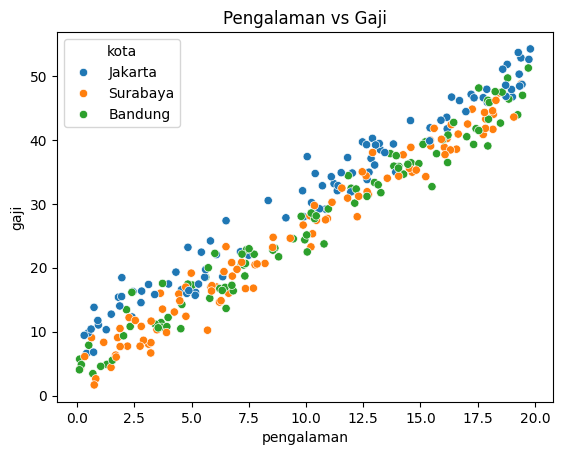

In [3]:
sns.scatterplot(
    data=df,
    x='pengalaman',
    y='gaji',
    hue='kota'
)

plt.title('Pengalaman vs Gaji')
plt.show()

In [4]:
df = pd.get_dummies(
    df,
    columns=['kota'],
    drop_first=True,
    dtype=int
)

print(df.columns)

Index(['pengalaman', 'edu', 'gaji', 'kota_Jakarta', 'kota_Surabaya'], dtype='object')


In [5]:
X = df.drop('gaji', axis=1)
y = df['gaji']

print(X.head())

   pengalaman  edu  kota_Jakarta  kota_Surabaya
0    7.490802    0             1              0
1   19.014286    1             1              0
2   14.639879    2             0              1
3   11.973170    2             0              0
4    3.120373    2             1              0


In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(240, 4)
(60, 4)


In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

In [8]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(
    X_train_s,
    y_train
)

print("Intercept:", model.intercept_)
print("Koefisien:", model.coef_)

Intercept: 27.514124756898322
Koefisien: [13.04224099  1.1878795   1.83722613 -0.29156083]


In [9]:
y_pred = model.predict(X_test_s)

print(y_pred[:5])

[42.89380034 36.87384692 10.5713704  37.35990762 31.73594551]


In [12]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print(f"MAE = {mae:.3f}")
print(f"RMSE = {rmse:.3f}")
print(f"R² = {r2:.3f}")

MAE = 1.649
RMSE = 2.123
R² = 0.974


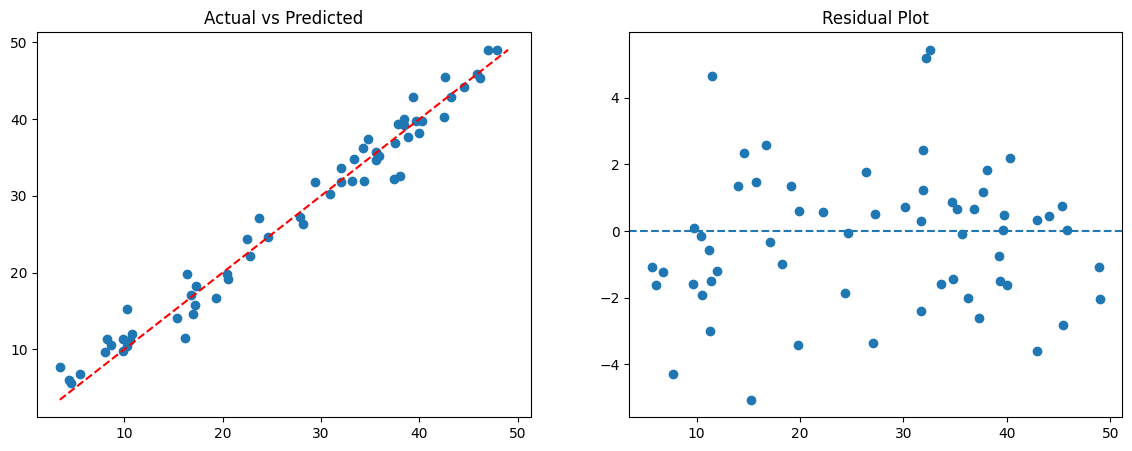

In [13]:
fig, axes = plt.subplots(1,2,figsize=(14,5))

# Actual vs Predicted
axes[0].scatter(y_test,y_pred)

lims = [
    min(y_test.min(),y_pred.min()),
    max(y_test.max(),y_pred.max())
]

axes[0].plot(
    lims,
    lims,
    'r--'
)

axes[0].set_title("Actual vs Predicted")

# Residual Plot
residuals = y_test - y_pred

axes[1].scatter(
    y_pred,
    residuals
)

axes[1].axhline(
    0,
    linestyle='--'
)

axes[1].set_title("Residual Plot")

plt.show()

Actual vs Predicted

Titik-titik berada dekat garis merah sehingga prediksi model sangat mendekati nilai aktual.

Residual Plot

Residual tersebar acak di sekitar garis nol. Hal ini menunjukkan model regresi linear telah bekerja dengan baik dan tidak ditemukan pola kesalahan yang signifikan.